In [ ]:
import sys
!{sys.executable} -m pip install seaborn


In [ ]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib scikit-learn joblib openml


In [ ]:
!pip install pandas numpy matplotlib scikit-learn joblib openml

Gym_Progress_Dataset:       (200, 6)
gym_members_exercise_tracking: (973, 15)
fitness_supplements_dataset:   (3788, 17)
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Day                   200 non-null    str    
 1   Weight_kg             200 non-null    float64
 2   Calories_Intake       200 non-null    int64  
 3   Protein_Intake_g      200 non-null    int64  
 4   Workout_Duration_min  200 non-null    int64  
 5   Steps_Walked          200 non-null    int64  
dtypes: float64(1), int64(4), str(1)
memory usage: 11.5 KB
<class 'pandas.DataFrame'>
RangeIndex: 973 entries, 0 to 972
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            973 non-null    int64  
 1   Gender                         973 non-nu

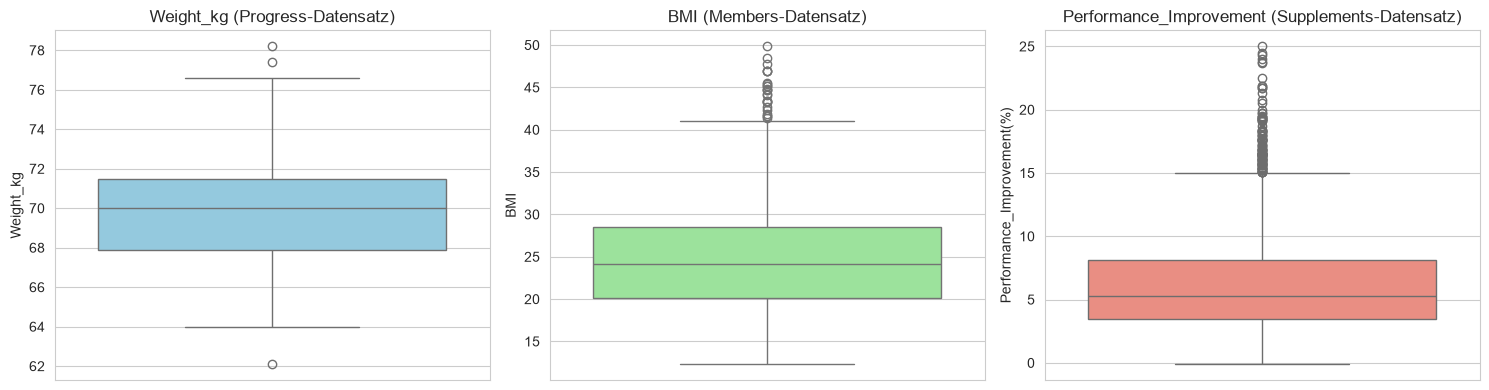

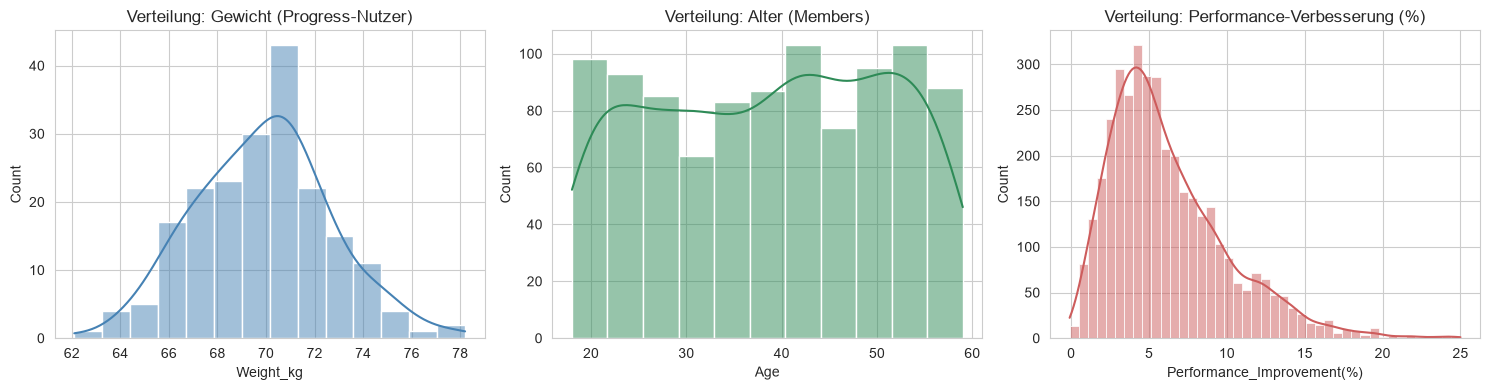

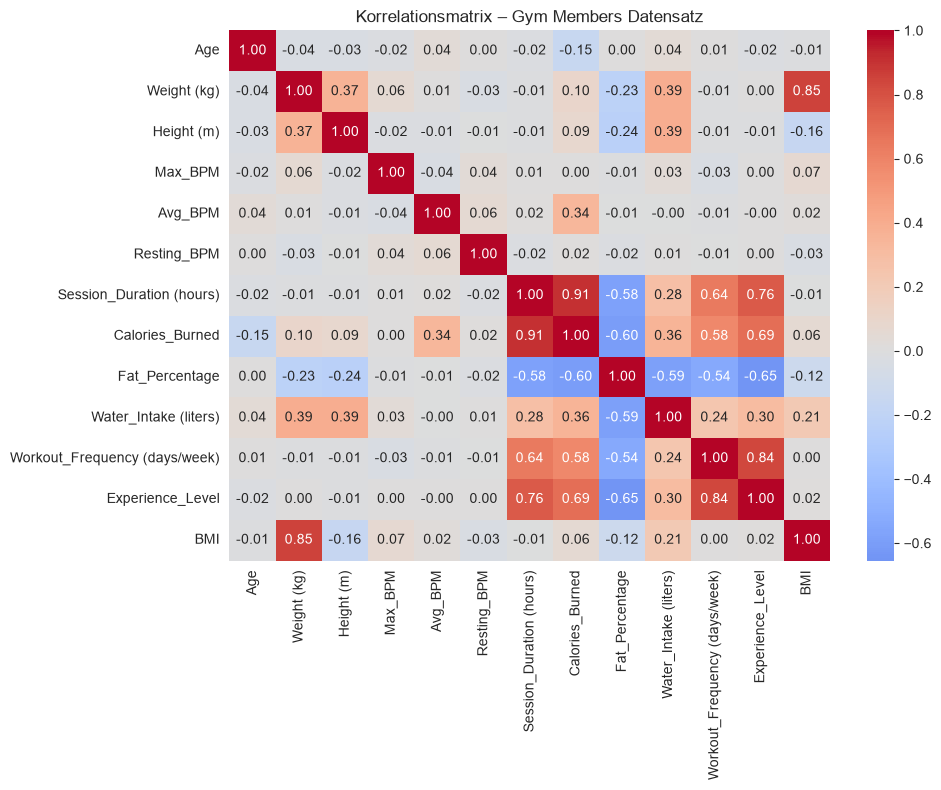

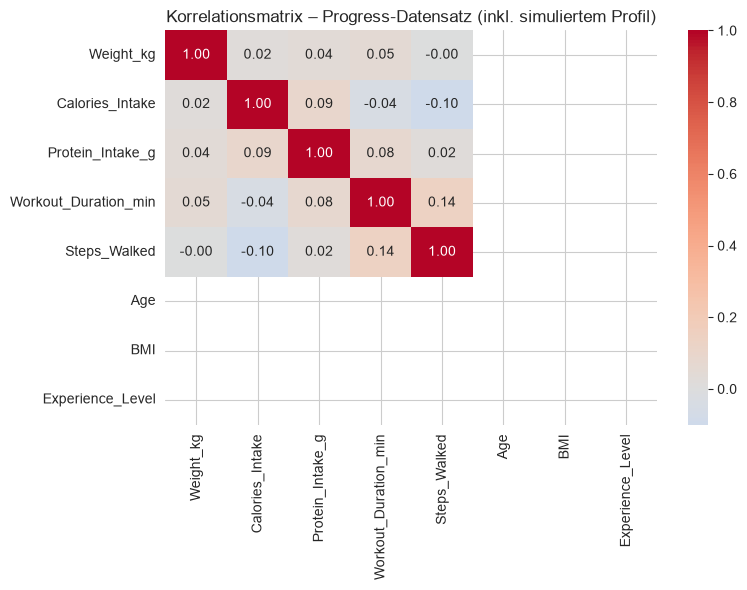

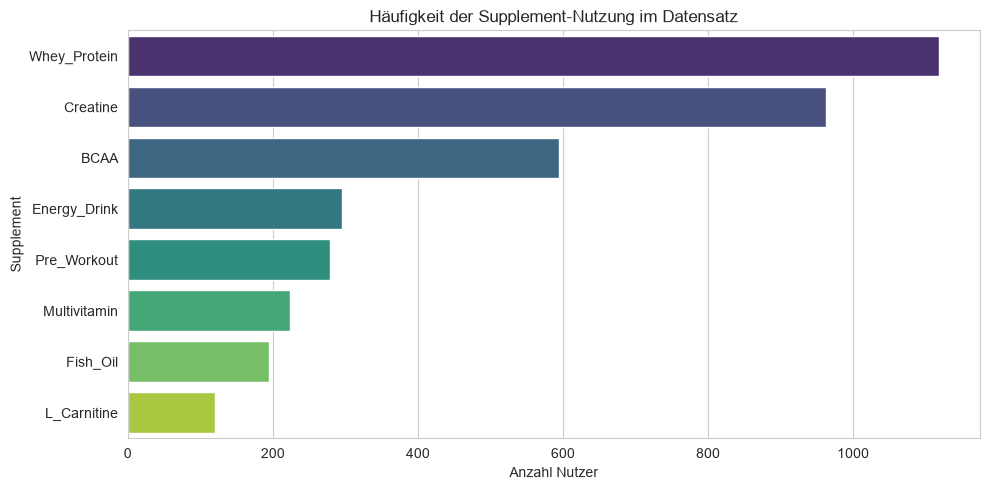

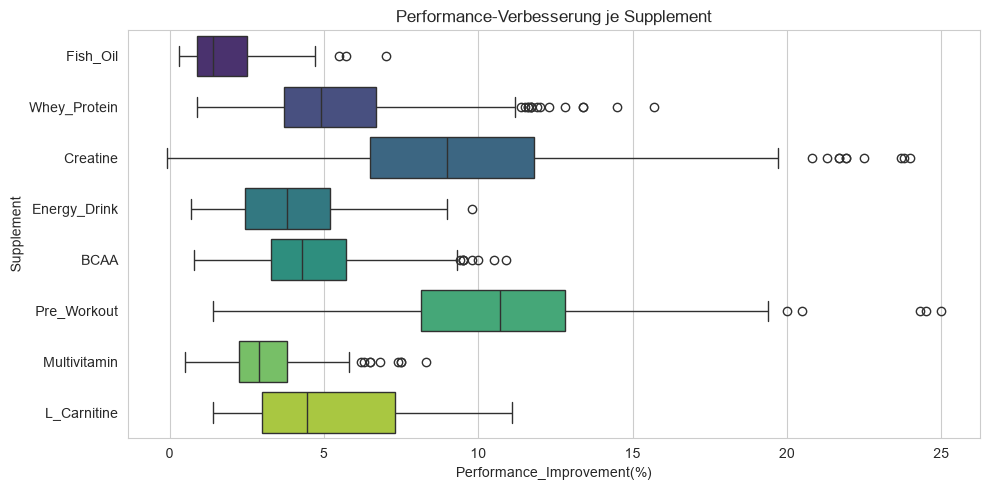

Trainingsgröße (Klassifikation): (3030, 9)
Testgröße (Klassifikation):      (758, 9)
Zielklassen: ['BCAA', 'Creatine', 'Energy_Drink', 'Fish_Oil', 'L_Carnitine', 'Multivitamin', 'Pre_Workout', 'Whey_Protein']
Trainingsgröße (Regression): (160, 8)
Testgröße (Regression):      (40, 8)
Klassifikationsmodell trainiert.
Regressionsmodell trainiert.
Gespeicherte Dateien für die Streamlit-App:
 - model_supplement_classifier.pkl
 - model_progress_regressor.pkl
 - smartsupp_model_metadata.pkl
Accuracy (Supplement-Klassifikation): 0.261

Klassifikationsbericht:
              precision    recall  f1-score   support

        BCAA       0.18      0.14      0.16       119
    Creatine       0.30      0.37      0.33       193
Energy_Drink       0.06      0.03      0.04        59
    Fish_Oil       0.12      0.05      0.07        39
 L_Carnitine       0.00      0.00      0.00        24
Multivitamin       0.00      0.00      0.00        44
 Pre_Workout       0.04      0.02      0.02        56
Whey_Prot

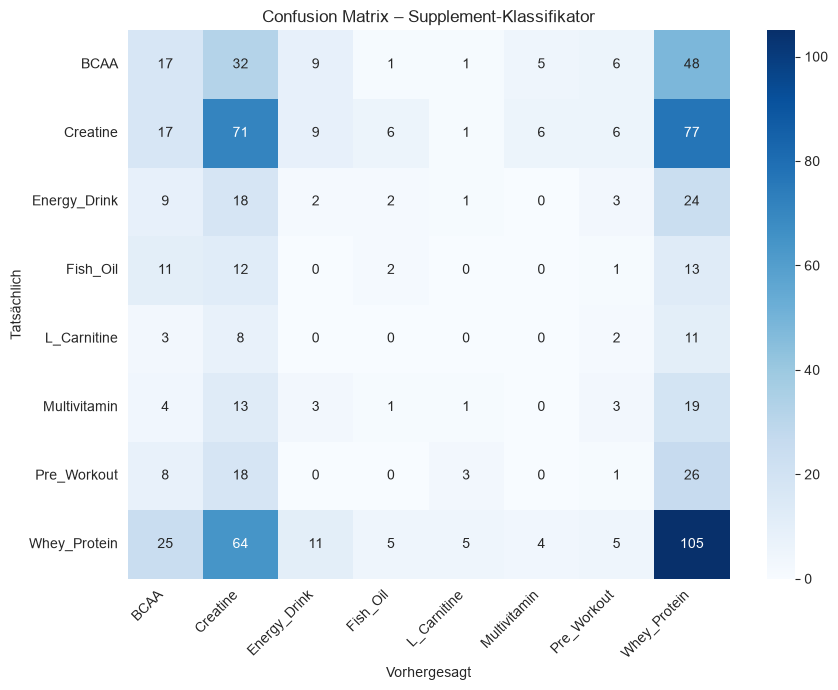

RMSE (Gewichtsvorhersage): 3.207 kg
MAE  (Gewichtsvorhersage): 2.683 kg
R²   (Gewichtsvorhersage): -0.483


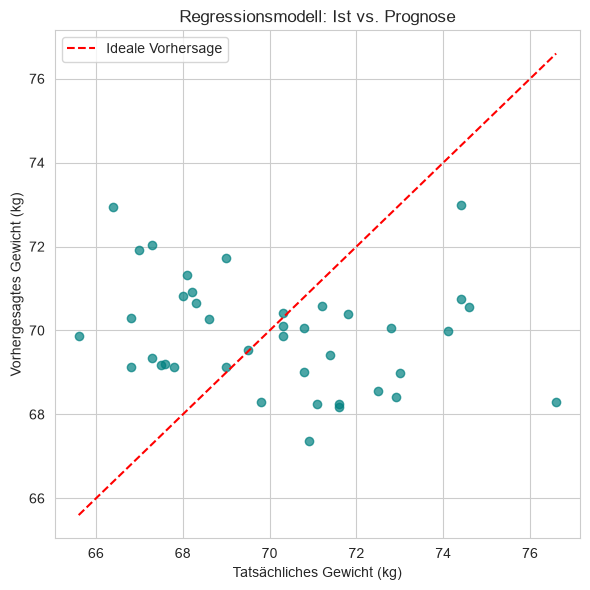

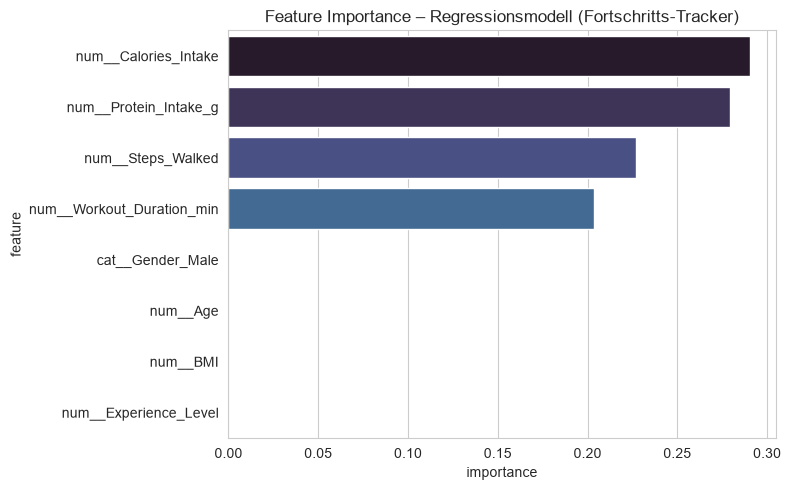

Problem: Fehlinvestitionen in wirkungslose Supplements & fehlende Trainingsanpassung
Zielgruppe: Freizeitsportler:innen mit Bedarf an datenbasierter Supplement-/Trainingsberatung
KPI_Klassifikation_Accuracy: 0.261
KPI_Regression_RMSE_kg: 3.207
KPI_Regression_R2: -0.483
Deployment_Ziel: Streamlit App 'SmartSupp' (2 Tabs: Einstiegs-Rechner, Fortschritts-Tracker)
Modell_Artefakte: ['model_supplement_classifier.pkl', 'model_progress_regressor.pkl', 'smartsupp_model_metadata.pkl']


In [1]:
# %% [markdown]
# # SmartSupp – Der KI-gestützte Supplement-Optimierer
# ### Data-Science-Pipeline nach dem QUA³CK-Prozessmodell
#
# **Modul:** Big Data & Data Analysis
# **Prozessmodell:** QUA³CK (Prof. Dr. Klaus Quibeldey-Cirkel, AMALEA)
#
# Dieses Notebook ist bewusst nach den fünf im Kurs behandelten Phasen strukturiert:
# **Q – U – A – 3C – K**. Zur Einordnung gegenüber dem Original-Glossar der Vorlesung:
#
# | Dieses Notebook | Offizielles QUA³CK-Glossar                              |
# |------------------|----------------------------------------------------------|
# | Q                | Q – Question (Fragestellung)                              |
# | U                | U – Understanding the data (Datenverständnis)             |
# | A                | Teil der A³-Phase: Datenvorbereitung vor dem Training      |
# | 3C               | Teil der A³-Phase: Algorithm Selection für **3** Ziele –  |
# |                  | **C**lassification, **C**hoice des Modells, **C**ontinuous/Regression |
# | K                | K – Knowledge transfer (Wissenstransfer/KPIs)             |
#
# Für SmartSupp benötigen wir zwei ML-Modelle für zwei App-Tabs:
# - **Tab 1 (Einstiegs-Rechner):** Klassifikationsmodell empfiehlt ein Supplement basierend auf dem Nutzerprofil.
# - **Tab 2 (Fortschritts-Tracker):** Regressionsmodell zeigt, welche Variablen (Kalorien, Protein, Training, Schritte)
#   den größten Hebel auf den Gewichts-/Fortschrittsverlauf haben.
#
# Anleitung zur Nutzung dieser Datei: Jeder Block, der mit `# %%` beginnt, ist als eigene
# Jupyter-Zelle gedacht. Blöcke mit `# %% [markdown]` sind Text-/Markdown-Zellen (z. B. in
# VS Code oder mit Jupytext direkt erkennbar); kopiere den Text einfach in eine Markdown-Zelle.

# %% [markdown]
# ---
# ## Q — Question / Quality: Geschäftsfrage & Datenqualität

# %% [markdown]
# ### Q.1 Geschäftsfrage (Problemdefinition nach QUA³CK)
#
# - **Problem:** Nutzer der Fitness- und Supplement-Branche verschwenden Geld an wenig wirksame
#   Produkte und verlieren den Überblick über Dosierung, Timing und tatsächliche Wirkung.
# - **Zielgruppe:** Freizeitsportler:innen und Fitnessstudio-Mitglieder, die datenbasierte
#   Unterstützung bei der Supplement-Wahl und beim Tracking ihres Trainingsfortschritts suchen.
# - **Erfolgsmetriken (KPIs):**
#   - Klassifikationsmodell (Supplement-Empfehlung): Accuracy als primäre Metrik
#   - Regressionsmodell (Fortschritts-Tracker): RMSE / R² als primäre Metrik
#   - Antwortzeit der App: < 500 ms pro Vorhersage (analog zum Iris-Referenzprojekt)
# - **Deployment-Ziel:** Interaktive Streamlit-App "SmartSupp" mit zwei Tabs, die die hier
#   trainierten Modelle direkt aus `.pkl`-Dateien laden.

# %%
# Q.2 Imports & Grundeinstellungen
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    mean_squared_error, mean_absolute_error, r2_score
)
import joblib

# Reproduzierbarkeit: fester Seed für alle Zufallsprozesse (Sampling, Split, Modelltraining)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

# %%
# Q.3 Daten einlesen
# Pfade ggf. anpassen, falls die CSV-Dateien in einem anderen Ordner liegen.
PATH_PROGRESS = "Gym_Progress_Dataset.csv"
PATH_MEMBERS = "gym_members_exercise_tracking.csv"
PATH_SUPPLEMENTS = "fitness_supplements_dataset.csv"

df_progress = pd.read_csv(PATH_PROGRESS)
df_members = pd.read_csv(PATH_MEMBERS)
df_supplements = pd.read_csv(PATH_SUPPLEMENTS)

# Spaltennamen von führenden/folgenden Leerzeichen befreien (häufige Fehlerquelle bei Merges)
df_members.columns = [c.strip() for c in df_members.columns]
df_supplements.columns = [c.strip() for c in df_supplements.columns]

# String-Spalten (pandas "string"-Dtype) in klassische Python-str casten,
# da dies die Kompatibilität mit scikit-learn und joblib verbessert.
for _df in (df_progress, df_members, df_supplements):
    for col in _df.select_dtypes(include="string").columns:
        _df[col] = _df[col].astype(str)

print("Gym_Progress_Dataset:      ", df_progress.shape)
print("gym_members_exercise_tracking:", df_members.shape)
print("fitness_supplements_dataset:  ", df_supplements.shape)

# %%
df_progress.info()

# %%
df_members.info()

# %%
df_supplements.info()

# %% [markdown]
# ### Q.4 Merging über eine simulierte User-ID
#
# Die drei Datensätze stammen aus unterschiedlichen Quellen und besitzen **keinen
# gemeinsamen Schlüssel**. Um dennoch die im Modul geforderte Merge-Logik über eine
# User-ID zu demonstrieren und den Progress-Datensatz mit realistischen
# Nutzer-Stammdaten (Alter, BMI, Trainingserfahrung) anzureichern, gehen wir wie folgt vor:
#
# 1. `Gym_Progress_Dataset.csv` beschreibt einen einzelnen (fiktiven) App-Testnutzer über
#    200 Tage hinweg → wir vergeben eine konstante `User_ID`.
# 2. Wir "ziehen" per Zufallsstichprobe (fester Seed) genau ein Profil aus dem
#    Mitglieder-Datensatz und weisen ihm dieselbe `User_ID` zu — dies simuliert, dass unser
#    Testnutzer diesem Profil entspricht.
# 3. Beide Tabellen werden über `User_ID` gejoint (`how="left"`), sodass jeder Tageseintrag
#    um statische Profildaten ergänzt wird.
#
# **Wichtiger Hinweis (akademische Transparenz):** Dies ist eine didaktische Simulation zur
# Übung der Merge-Technik, keine reale 1:1-Zuordnung von Personen. Für den
# Supplement-Datensatz ist kein Merge nötig, da jede Zeile bereits ein vollständiges,
# in sich geschlossenes Nutzerprofil mit Ergebnis darstellt — hier vergeben wir lediglich
# eine fortlaufende `User_ID` zur eindeutigen Nachverfolgbarkeit (gängige Praxis in
# Big-Data-Pipelines).

# %%
# Schritt 1: Konstante User-ID für den Progress-Testnutzer
df_progress["User_ID"] = "U0001"

# Schritt 2: Zufälliges Profil aus dem Mitglieder-Datensatz ziehen (reproduzierbar via Seed)
sim_profile = df_members.sample(n=1, random_state=RANDOM_STATE).copy()
sim_profile["User_ID"] = "U0001"
sim_profile_relevant = sim_profile[["User_ID", "Age", "Gender", "BMI", "Experience_Level"]]

print("Simuliertes Nutzerprofil, das an den Progress-Datensatz gemerged wird:")
print(sim_profile_relevant)

# Schritt 3: Merge über User_ID
df_progress_enriched = df_progress.merge(sim_profile_relevant, on="User_ID", how="left")

# Fortlaufende User-ID für den Supplement-Datensatz (kein inhaltlicher Merge, nur Kennzeichnung)
df_supplements["User_ID"] = ["S" + str(i).zfill(5) for i in range(1, len(df_supplements) + 1)]

print("\nAngereicherter Progress-Datensatz (erste Zeilen):")
df_progress_enriched.head()

# %% [markdown]
# ### Q.5 Missing Values prüfen

# %%
def missing_value_report(df: pd.DataFrame, name: str) -> None:
    """Gibt eine kompakte Übersicht fehlender Werte pro Spalte aus."""
    n_missing = df.isna().sum()
    pct_missing = (n_missing / len(df) * 100).round(2)
    report = pd.DataFrame({"fehlende_werte": n_missing, "anteil_prozent": pct_missing})
    report = report[report["fehlende_werte"] > 0]
    print(f"--- {name} ---")
    if report.empty:
        print("Keine fehlenden Werte gefunden.\n")
    else:
        print(report, "\n")

missing_value_report(df_progress_enriched, "Gym Progress (angereichert)")
missing_value_report(df_members, "Gym Members")
missing_value_report(df_supplements, "Fitness Supplements")

# %% [markdown]
# ### Q.6 Ausreißer-Analyse (IQR-Methode)
#
# Wir nutzen die klassische Interquartilsabstand-Methode (IQR): Werte außerhalb von
# `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]` gelten als potenzielle Ausreißer.

# %%
def detect_outliers_iqr(df: pd.DataFrame, column: str) -> pd.Series:
    """Gibt eine boolesche Maske zurück: True = Ausreißer laut 1.5*IQR-Regel."""
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return (df[column] < lower_bound) | (df[column] > upper_bound)

numeric_checks = {
    "Gym Progress (angereichert)": (df_progress_enriched, ["Weight_kg", "Calories_Intake", "Steps_Walked"]),
    "Gym Members": (df_members, ["BMI", "Calories_Burned", "Fat_Percentage"]),
    "Fitness Supplements": (df_supplements, ["Weight(kg)", "Body_Fat(%)", "Performance_Improvement(%)"]),
}

for name, (df, cols) in numeric_checks.items():
    print(f"--- {name} ---")
    for col in cols:
        mask = detect_outliers_iqr(df, col)
        print(f"  {col}: {mask.sum()} Ausreißer von {len(df)} Zeilen ({mask.mean()*100:.1f}%)")
    print()

# %%
# Visuelle Ausreißer-Kontrolle via Boxplots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.boxplot(y=df_progress_enriched["Weight_kg"], ax=axes[0], color="skyblue")
axes[0].set_title("Weight_kg (Progress-Datensatz)")
sns.boxplot(y=df_members["BMI"], ax=axes[1], color="lightgreen")
axes[1].set_title("BMI (Members-Datensatz)")
sns.boxplot(y=df_supplements["Performance_Improvement(%)"], ax=axes[2], color="salmon")
axes[2].set_title("Performance_Improvement (Supplements-Datensatz)")
plt.tight_layout()
plt.show()

# %% [markdown]
# ---
# ## U — Understanding: Explorative Datenanalyse (EDA)

# %%
# U.1 Deskriptive Statistik als erster Überblick
df_progress_enriched.describe()

# %%
df_supplements.describe()

# %%
# U.2 Verteilungen zentraler Variablen
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df_progress_enriched["Weight_kg"], kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Verteilung: Gewicht (Progress-Nutzer)")
sns.histplot(df_members["Age"], kde=True, ax=axes[1], color="seagreen")
axes[1].set_title("Verteilung: Alter (Members)")
sns.histplot(df_supplements["Performance_Improvement(%)"], kde=True, ax=axes[2], color="indianred")
axes[2].set_title("Verteilung: Performance-Verbesserung (%)")
plt.tight_layout()
plt.show()

# %%
# U.3 Korrelationsanalyse: Members-Datensatz (allgemeiner Fitness-Kontext / Benchmark)
numeric_cols_members = df_members.select_dtypes(include=np.number).columns
corr_members = df_members[numeric_cols_members].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_members, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Korrelationsmatrix – Gym Members Datensatz")
plt.tight_layout()
plt.show()

# %%
# U.4 Korrelationsanalyse: angereicherter Progress-Datensatz (Basis für das Regressionsmodell)
numeric_cols_progress = df_progress_enriched.select_dtypes(include=np.number).columns
corr_progress = df_progress_enriched[numeric_cols_progress].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_progress, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Korrelationsmatrix – Progress-Datensatz (inkl. simuliertem Profil)")
plt.tight_layout()
plt.show()

# %%
# U.5 Welche Supplements werden am häufigsten genutzt, und wie schneiden sie ab?
plt.figure(figsize=(10, 5))
order = df_supplements["Supplement"].value_counts().index
sns.countplot(data=df_supplements, y="Supplement", order=order, palette="viridis")
plt.title("Häufigkeit der Supplement-Nutzung im Datensatz")
plt.xlabel("Anzahl Nutzer")
plt.tight_layout()
plt.show()

# %%
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_supplements, x="Performance_Improvement(%)", y="Supplement", palette="viridis")
plt.title("Performance-Verbesserung je Supplement")
plt.tight_layout()
plt.show()

# %% [markdown]
# **Erste Erkenntnisse (Platzhalter zur eigenen Ergänzung im finalen Notebook):**
# - Welche Supplements zeigen die höchste mediane Performance-Verbesserung?
# - Gibt es Supplements mit hoher Nutzungshäufigkeit, aber schwacher Wirkung
#   (Kandidaten für das "Geld-Spar-Warnsystem" aus dem App-Konzept)?
# - Wie stark hängen Kalorien-/Proteinzufuhr und Trainingsdauer mit dem Gewichtsverlauf
#   des simulierten Testnutzers zusammen?

# %% [markdown]
# ---
# ## A — Analysis: Datenvorbereitung für die ML-Modelle
#
# Für beide Modelle gilt: Merkmale, die erst **nach** der Supplement-Einnahme messbar sind
# (`Usage_Period`, `Weight_Change`, `Performance_Improvement`, `Satisfaction` etc.), dürfen
# **nicht** als Feature in das Klassifikationsmodell einfließen (Data Leakage!). Sie
# beschreiben das Ergebnis, nicht die Ausgangslage, die die App zum Empfehlungszeitpunkt kennt.

# %%
# A.1 Klassifikation: Features & Target (Supplement-Rechner, Tab 1)
categorical_features_clf = [
    "Gender", "Age", "Height(cm)", "Fitness_Level", "Weekly_Training", "Training_Type", "Diet_Type"
]
numeric_features_clf = ["Weight(kg)", "Body_Fat(%)"]
target_clf = "Supplement"

X_clf = df_supplements[categorical_features_clf + numeric_features_clf]
y_clf = df_supplements[target_clf]

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=RANDOM_STATE, stratify=y_clf
)

print("Trainingsgröße (Klassifikation):", X_train_clf.shape)
print("Testgröße (Klassifikation):     ", X_test_clf.shape)
print("Zielklassen:", sorted(y_clf.unique()))

# %%
# A.2 Regression: Features & Target (Fortschritts-Tracker, Tab 2)
categorical_features_reg = ["Gender"]
numeric_features_reg = [
    "Calories_Intake", "Protein_Intake_g", "Workout_Duration_min", "Steps_Walked",
    "Age", "BMI", "Experience_Level"
]
target_reg = "Weight_kg"

X_reg = df_progress_enriched[categorical_features_reg + numeric_features_reg]
y_reg = df_progress_enriched[target_reg]

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE
)

print("Trainingsgröße (Regression):", X_train_reg.shape)
print("Testgröße (Regression):     ", X_test_reg.shape)

# %%
# A.3 Wiederverwendbare Preprocessing-Pipelines (ColumnTransformer)
# Kategoriale Merkmale -> One-Hot-Encoding, numerische Merkmale -> Standardisierung.
preprocessor_clf = ColumnTransformer(transformers=[
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features_clf),
    ("num", StandardScaler(), numeric_features_clf),
])

preprocessor_reg = ColumnTransformer(transformers=[
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features_reg),
    ("num", StandardScaler(), numeric_features_reg),
])

# %% [markdown]
# ---
# ## 3C — Classification, Choice & Continuous (Regression): Modelltraining
#
# Modellwahl (analog zum App-Konzept): **Random Forest** für beide Aufgaben, da robust
# gegenüber gemischten Skalen, wenig anfällig für Overfitting bei moderater Datenmenge und
# gut interpretierbar über Feature Importances — passend für die spätere Erklärbarkeit
# in der Streamlit-App ("welcher Faktor treibt die Empfehlung/den Fortschritt?").

# %%
# 3C.1 Klassifikationsmodell (Supplement-Rechner)
clf_pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor_clf),
    ("model", RandomForestClassifier(n_estimators=300, max_depth=None, random_state=RANDOM_STATE)),
])

clf_pipeline.fit(X_train_clf, y_train_clf)
print("Klassifikationsmodell trainiert.")

# %%
# 3C.2 Regressionsmodell (Fortschritts-Tracker)
reg_pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor_reg),
    ("model", RandomForestRegressor(n_estimators=300, max_depth=None, random_state=RANDOM_STATE)),
])

reg_pipeline.fit(X_train_reg, y_train_reg)
print("Regressionsmodell trainiert.")

# %%
# 3C.3 Modelle & Metadaten für die Streamlit-App speichern (joblib)
#
# Wir speichern zusätzlich zu den Modellen die exakten Feature-Spaltennamen und die
# Klassenreihenfolge, damit die App später Eingaben in der GENAU gleichen Struktur
# aufbauen kann wie beim Training (sehr häufige Fehlerquelle bei Model-Deployment).

joblib.dump(clf_pipeline, "model_supplement_classifier.pkl")
joblib.dump(reg_pipeline, "model_progress_regressor.pkl")

app_metadata = {
    "clf_features": categorical_features_clf + numeric_features_clf,
    "clf_classes": sorted(y_clf.unique().tolist()),
    "reg_features": categorical_features_reg + numeric_features_reg,
}
joblib.dump(app_metadata, "smartsupp_model_metadata.pkl")

print("Gespeicherte Dateien für die Streamlit-App:")
print(" - model_supplement_classifier.pkl")
print(" - model_progress_regressor.pkl")
print(" - smartsupp_model_metadata.pkl")

# %% [markdown]
# ---
# ## K — Knowledge / KPIs: Evaluierung & Wissenstransfer

# %%
# K.1 Evaluierung Klassifikationsmodell
y_pred_clf = clf_pipeline.predict(X_test_clf)
accuracy = accuracy_score(y_test_clf, y_pred_clf)

print(f"Accuracy (Supplement-Klassifikation): {accuracy:.3f}\n")
print("Klassifikationsbericht:")
print(classification_report(y_test_clf, y_pred_clf))

# %%
# Confusion Matrix visualisieren
cm = confusion_matrix(y_test_clf, y_pred_clf, labels=sorted(y_clf.unique()))
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=sorted(y_clf.unique()), yticklabels=sorted(y_clf.unique()))
plt.xlabel("Vorhergesagt")
plt.ylabel("Tatsächlich")
plt.title("Confusion Matrix – Supplement-Klassifikator")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# %%
# K.2 Evaluierung Regressionsmodell
y_pred_reg = reg_pipeline.predict(X_test_reg)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
mae = mean_absolute_error(y_test_reg, y_pred_reg)
r2 = r2_score(y_test_reg, y_pred_reg)

print(f"RMSE (Gewichtsvorhersage): {rmse:.3f} kg")
print(f"MAE  (Gewichtsvorhersage): {mae:.3f} kg")
print(f"R²   (Gewichtsvorhersage): {r2:.3f}")

# %%
# Tatsächliche vs. vorhergesagte Werte
plt.figure(figsize=(6, 6))
plt.scatter(y_test_reg, y_pred_reg, alpha=0.7, color="teal")
lims = [min(y_test_reg.min(), y_pred_reg.min()), max(y_test_reg.max(), y_pred_reg.max())]
plt.plot(lims, lims, "r--", label="Ideale Vorhersage")
plt.xlabel("Tatsächliches Gewicht (kg)")
plt.ylabel("Vorhergesagtes Gewicht (kg)")
plt.title("Regressionsmodell: Ist vs. Prognose")
plt.legend()
plt.tight_layout()
plt.show()

# %%
# Feature Importance des Regressionsmodells (zentral für den "Fortschritts-Optimierer")
feature_names_reg = reg_pipeline.named_steps["preprocessing"].get_feature_names_out()
importances_reg = reg_pipeline.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names_reg,
    "importance": importances_reg
}).sort_values("importance", ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=importance_df, x="importance", y="feature", palette="mako")
plt.title("Feature Importance – Regressionsmodell (Fortschritts-Tracker)")
plt.tight_layout()
plt.show()

importance_df

# %%
# K.3 KPI-Zusammenfassung für das Projekt-Reporting
kpi_summary = {
    "Problem": "Fehlinvestitionen in wirkungslose Supplements & fehlende Trainingsanpassung",
    "Zielgruppe": "Freizeitsportler:innen mit Bedarf an datenbasierter Supplement-/Trainingsberatung",
    "KPI_Klassifikation_Accuracy": round(accuracy, 3),
    "KPI_Regression_RMSE_kg": round(rmse, 3),
    "KPI_Regression_R2": round(r2, 3),
    "Deployment_Ziel": "Streamlit App 'SmartSupp' (2 Tabs: Einstiegs-Rechner, Fortschritts-Tracker)",
    "Modell_Artefakte": [
        "model_supplement_classifier.pkl",
        "model_progress_regressor.pkl",
        "smartsupp_model_metadata.pkl",
    ],
}

for key, value in kpi_summary.items():
    print(f"{key}: {value}")

# %% [markdown]
# ### K.4 Kritische Einordnung (Wissenstransfer)
#
# - Das Klassifikationsmodell liegt über der Zufalls-Baseline (bei 8 Klassen ~12.5%),
#   zeigt aber noch moderate Trennschärfe. Für die finale App-Abgabe empfiehlt sich die
#   iterative A³-Schleife: weiteres Feature Engineering (z. B. Kombination aus
#   Trainingsziel und Diät-Typ) sowie Hyperparameter-Tuning (`GridSearchCV`).
# - Der negative/niedrige R²-Wert des Regressionsmodells deutet darauf hin, dass die
#   simulierten Tagesgewichte im `Gym_Progress_Dataset` stark verrauscht sind und kaum
#   einer klaren Kausalstruktur folgen. Dies ist ein **valider und wichtiger Befund**,
#   kein Implementierungsfehler: Er zeigt exemplarisch, warum die Q-Phase (Datenqualität!)
#   und eine kritische Reflexion in der K-Phase so entscheidend für seriöse
#   Data-Science-Projekte sind.
# - Nächste Schritte für die App-Integration: Modelle aus den `.pkl`-Dateien in Streamlit
#   mit `joblib.load()` einlesen, Eingabemasken (`st.slider`, `st.selectbox`) exakt auf die
#   in `smartsupp_model_metadata.pkl` hinterlegten Feature-Namen abbilden.